In [1]:
# Importing libraries
import os
import sys
import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib        as mpl
import matplotlib.pyplot as plt
from   nilearn.image import load_img, resample_to_img, coord_transform
from   nilearn.glm   import threshold_stats_img
from   nilearn       import plotting, datasets
from   scipy.stats   import norm
from   copy          import deepcopy
# Importing custom libraries
sys.path.append("..")
from scripts.util     import *
from scripts.subjects import Subject

In [2]:
# Loading the data-frame
# The dataframe consists of all subject-wise task-related, demographic, and psychometric variables
df = BEHAVIOR.copy()
# Loading the subjects
subjects = Subject.get_subjects() # Initial Cohort
print(f"Number of subjects in Initial Cohort: {len(subjects)}")
# Filtering the data-frame for only these subjects
data = df[df['subID'].isin(Subject.get_subids(subjects))].copy()
data

Number of subjects in Initial Cohort: 108


,subID,age,sex,hand,patient,consumption_score,devaluation_ratio,rate,slope_run_1,slope_run_2,...,STAI_Total,LSPS_Total,AUDIT_Total,EAT_Total,PDSS_Total,PSWQ_Total,BDI_Total,Apath_Total,BISBAS-BIS_Total,BIS_Total
0,2,34.0,1.0,1.0,0.0,10.0,0.725000,2.171884,0.034451,0.072361,...,37.0,1.0,1.0,5.0,2.0,44.0,5.0,23.0,14.0,63.0
1,3,33.0,0.0,1.0,0.0,10.0,0.451737,2.081242,0.080928,0.029228,...,46.0,47.0,3.0,5.0,0.0,57.0,12.0,42.0,21.0,58.0
2,4,32.0,0.0,0.0,0.0,10.0,0.682266,2.783749,0.119622,0.011302,...,20.0,3.0,10.0,4.0,0.0,35.0,0.0,21.0,13.0,56.0
3,7,30.0,0.0,1.0,0.0,10.0,0.534125,1.823994,0.155464,-0.094875,...,52.0,23.0,4.0,3.0,0.0,36.0,3.0,NaN,22.0,67.0
4,10,34.0,0.0,1.0,0.0,10.0,0.908163,4.196153,0.253462,0.032995,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,186,23.0,1.0,1.0,0.0,10.0,0.493243,2.006469,0.040218,0.086782,...,52.0,46.0,3.0,13.0,0.0,54.0,10.0,34.0,23.0,75.0
138,188,35.0,1.0,1.0,0.0,10.0,0.596215,2.390084,0.076821,-0.145699,...,30.0,19.0,6.0,1.0,0.0,37.0,0.0,23.0,22.0,71.0
144,197,25.0,0.0,1.0,0.0,10.0,0.854305,2.511604,-0.011575,-0.109254,...,46.0,38.0,5.0,9.0,0.0,70.0,11.0,23.0,28.0,67.0
148,202,24.0,1.0,1.0,0.0,10.0,1.000000,2.887522,0.101371,0.023956,...,31.0,63.0,5.0,4.0,0.0,35.0,0.0,25.0,22.0,70.0


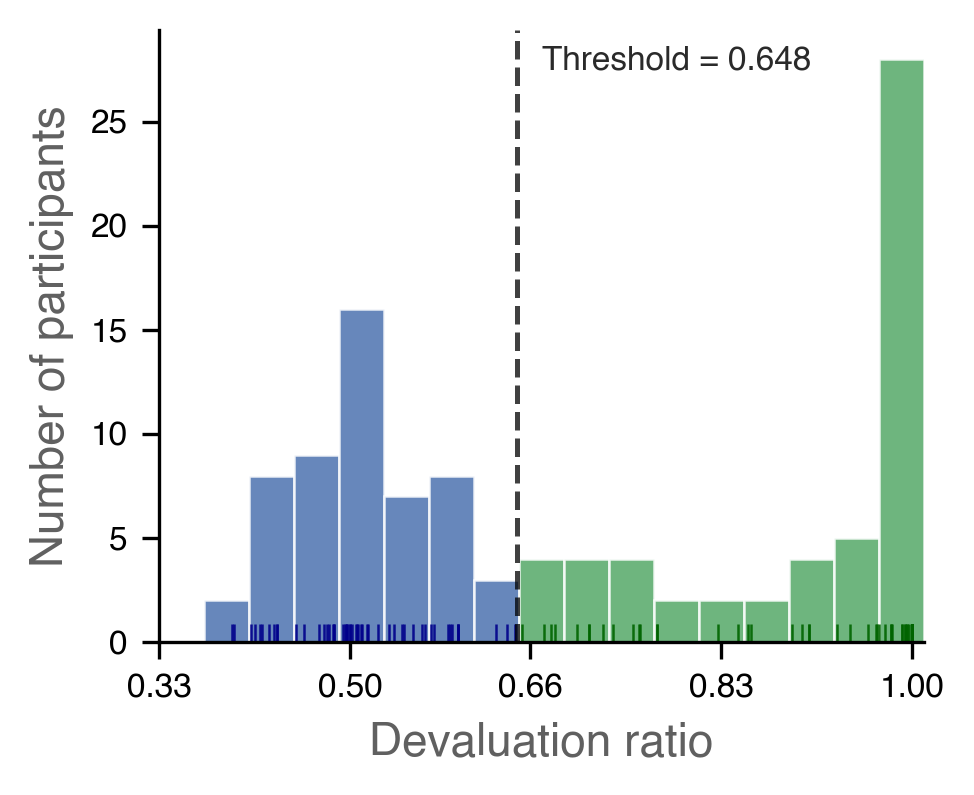

In [3]:
# Muted, print-safe
COLOR_HABIT         = "#4C72B0"
COLOR_GOAL          = "#55A868"
AXIS_LABEL_COLOR    = "#606060"


def apply_panel_style():
    mpl.rcParams.update({
        "font.family"       : "sans-serif",
        "font.sans-serif"   : ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size"         : 9,
        "axes.labelsize"    : 9,
        "xtick.labelsize"   : 8,
        "ytick.labelsize"   : 8,
        "axes.linewidth"    : 0.8,
        "figure.dpi"        : 300,
        "savefig.dpi"       : 300,
    })


def plot_devaluation_ratio_hist(
    dr        : np.ndarray,
    *,
    cutoff    : float = 0.648,
    xmin      : float = 0.33,
    xmax      : float = 1.01,
    binwidth  : float = 0.04,
    outpath   : str | None = None,
    figsize   : tuple[float, float] = (3.2, 2.6),
) -> tuple[plt.Figure, plt.Axes]:
    dr = np.asarray(dr, dtype=float)
    dr = dr[np.isfinite(dr)]

    bins        = np.arange(xmin, xmax + binwidth, binwidth)
    habitual    = dr[dr < cutoff]
    goal        = dr[dr >= cutoff]

    fig, ax = plt.subplots(figsize=figsize)

    hist_kw = dict(bins=bins, density=False, linewidth=0.6, edgecolor="white")
    ax.hist(habitual, color=COLOR_HABIT, alpha=0.85, label="Habitual", **hist_kw)
    ax.hist(goal,     color=COLOR_GOAL,  alpha=0.85, label="Goal-directed", **hist_kw)

    ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.2, alpha=0.75, zorder=5)

    # rug (matplotlib only)
    y0, y1 = ax.get_ylim()
    rug_h  = 0.03 * (y1 - y0)
    if habitual.size:
        ax.vlines(habitual, y0, y0 + rug_h, color="darkblue", linewidth=0.6, alpha=0.9)
    if goal.size:
        ax.vlines(goal, y0, y0 + rug_h, color="darkgreen", linewidth=0.6, alpha=0.9)

    ax.set_xlabel("Devaluation ratio", fontsize=11, color=AXIS_LABEL_COLOR)
    ax.set_ylabel("Number of participants", fontsize=11, color=AXIS_LABEL_COLOR)

    ax.set_xlim(xmin, xmax)
    xticks = [0.33, 0.50, 0.66, 0.83, 1.00]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{t:.2f}" for t in xticks])

    ax.annotate(
        f"Threshold = {cutoff:.3f}",
        xy=(cutoff, 0.95),
        xycoords=("data", "axes fraction"),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="#2A2A2A",
    )

    ax.tick_params(axis="both", width=0.8, length=4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout(pad=0.6)

    if outpath is not None:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, transparent=False, dpi=300)

    return fig, ax


# Example usage:
apply_panel_style()
fig, ax = plot_devaluation_ratio_hist(
    data["devaluation_ratio"].to_numpy(),
    cutoff=0.648,
    outpath=os.path.join(FIGURES_DIRECTORY, "figure-2_panel-A.png"),
)


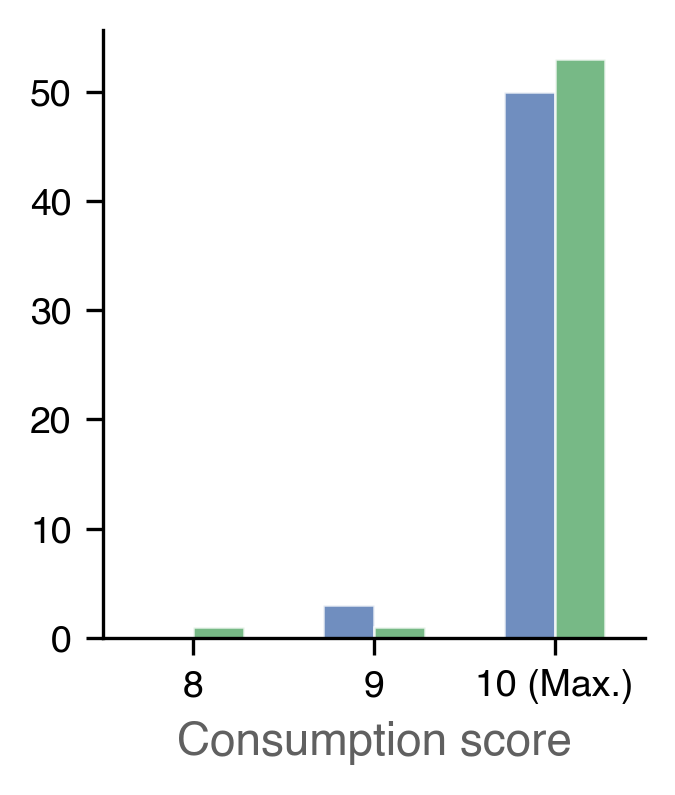

In [4]:
COLOR_HABIT      = "#4C72B0"
COLOR_GOAL       = "#55A868"
AXIS_LABEL_COLOR = "#606060"


def apply_panel_style():
    mpl.rcParams.update({
        "font.family"       : "sans-serif",
        "font.sans-serif"   : ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size"         : 9,
        "axes.labelsize"    : 9,
        "xtick.labelsize"   : 8,
        "ytick.labelsize"   : 8,
        "axes.linewidth"    : 0.8,
        "figure.dpi"        : 300,
        "savefig.dpi"       : 300,
    })


def plot_consumption_score_bars(
    dr: np.ndarray,
    cons: np.ndarray,
    *,
    cutoff: float = 0.648,
    outpath: str | None = None,
    figsize: tuple[float, float] = (2.2, 2.6),
) -> tuple[plt.Figure, plt.Axes]:
    dr = np.asarray(dr, dtype=float)
    cons = np.asarray(cons, dtype=float)

    is_goal = dr >= cutoff
    cons_habit = cons[~is_goal]
    cons_goal  = cons[is_goal]

    scores = np.array([8, 9, 10])
    counts_h = np.array([(cons_habit == s).sum() for s in scores])
    counts_g = np.array([(cons_goal  == s).sum() for s in scores])

    fig, ax = plt.subplots(figsize=figsize)

    w = 0.28
    ax.bar(
        scores - w/2, counts_h, width=w,
        color=COLOR_HABIT, edgecolor="white", linewidth=0.6, alpha=0.8,
        label="Habitual",
    )
    ax.bar(
        scores + w/2, counts_g, width=w,
        color=COLOR_GOAL, edgecolor="white", linewidth=0.6, alpha=0.8,
        label="Goal-directed",
    )

    ax.set_xlabel("Consumption score", fontsize=11, color=AXIS_LABEL_COLOR)
    ax.set_ylabel("", fontsize=11, color=AXIS_LABEL_COLOR)

    ax.set_xticks(scores)
    ax.set_xticklabels(["8", "9", "10 (Max.)"], fontsize=9)
    ax.set_xlim(7.5, 10.5)

    ax.tick_params(axis="both", width=0.8, length=4, labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout(pad=0.6)

    if outpath is not None:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, transparent=False)

    return fig, ax


# Example usage:
apply_panel_style()
fig, ax = plot_consumption_score_bars(
    data["devaluation_ratio"].to_numpy(),
    data["consumption_score"].to_numpy(),
    cutoff=0.648,
    outpath=os.path.join(FIGURES_DIRECTORY, "figure-2_panel-B.png"),
)


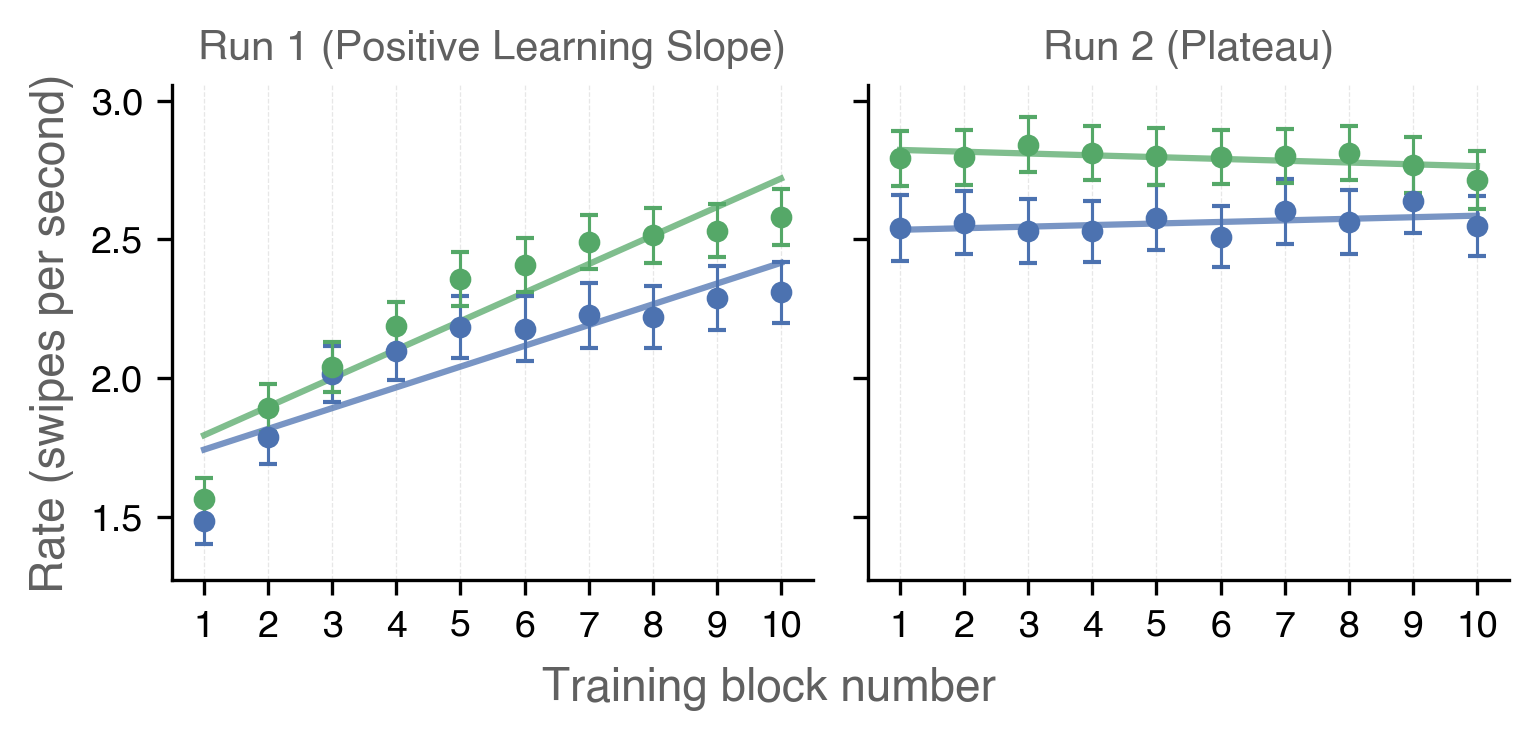

In [5]:
COLOR_HABIT      = "#4C72B0"
COLOR_GOAL       = "#55A868"
AXIS_LABEL_COLOR = "#606060"

GROUP_ORDER = ["Habitual", "Goal-directed"]
GROUP_COLOR = {"Habitual": COLOR_HABIT, "Goal-directed": COLOR_GOAL}


def plot_response_rate_panel_c(
    RATE,
    BEHAVIOR,
    *,
    cutoff: float = 0.648,
    FIGURES_DIRECTORY: str,
    outname: str = "figure-2_panel-C.png",
    COL_PID: str = "subID",
    COL_RUN: str = "runID",
    COL_BLOCK: str = "blockID",
    COL_RATE: str = "rate",
) -> tuple[plt.Figure, np.ndarray]:
    rate_df = RATE.copy()

    deval_map = BEHAVIOR.set_index(COL_PID)["devaluation_ratio"].to_dict()
    rate_df["devaluation_ratio"] = rate_df[COL_PID].map(deval_map)

    rate_df["group"] = np.where(
        rate_df["devaluation_ratio"] < cutoff,
        "Habitual",
        "Goal-directed",
    )

    df = rate_df.copy()
    df = df.dropna(subset=[COL_RUN, COL_BLOCK, "group", COL_RATE])
    df[COL_BLOCK] = df[COL_BLOCK].astype(int)
    df[COL_RUN] = df[COL_RUN].replace({"Run 1": 1, "Run 2": 2}).astype(int)

    summary = (
        df.groupby([COL_RUN, COL_BLOCK, "group"])[COL_RATE]
          .agg(mean="mean", std="std", n="count")
          .reset_index()
    )
    summary["sem"] = summary["std"] / np.sqrt(summary["n"])

    fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.6), sharey=True)

    for ax, run in zip(axes, [1, 2]):
        sub = summary[summary[COL_RUN] == run]

        for g in GROUP_ORDER:
            s = sub[sub["group"] == g].sort_values(COL_BLOCK)
            x = s[COL_BLOCK].to_numpy()
            y = s["mean"].to_numpy()
            e = s["sem"].to_numpy()

            ax.errorbar(
                x, y, yerr=e,
                fmt="o",
                markersize=4.2,
                capsize=2.2,
                elinewidth=0.75,
                linewidth=0,
                color=GROUP_COLOR[g],
                zorder=3,
            )

            if len(x) >= 2:
                m, b = np.polyfit(x, y, 1)
                xx = np.linspace(x.min(), x.max(), 100)
                ax.plot(
                    xx, m * xx + b,
                    linewidth=1.5,
                    color=GROUP_COLOR[g],
                    zorder=2,
                    alpha=0.75,
                )

        if run == 1:
            ax.set_title("Run 1 (Positive Learning Slope)", fontsize=10, color=AXIS_LABEL_COLOR)
        elif run == 2:
            ax.set_title("Run 2 (Plateau)", fontsize=10, color=AXIS_LABEL_COLOR)

        ax.set_xlim(0.5, 10.5)
        ax.set_xticks(range(1, 11))
        ax.set_xticklabels(range(1, 11), fontsize=9)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.grid(True, axis="x", linestyle="--", linewidth=0.3, alpha=0.3)
        ax.yaxis.grid(False)

        yticks = [round(tick, 2) for tick in np.linspace(1.5, 3.0, 4)]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontsize=9)

    axes[0].set_ylabel("Rate (swipes per second)", fontsize=11, color=AXIS_LABEL_COLOR)

    ymin = summary["mean"].min() - summary["sem"].max()
    ymax = summary["mean"].max() + summary["sem"].max()
    pad = 0.06 * (ymax - ymin if ymax > ymin else 1)

    for ax in axes:
        ax.set_ylim(ymin - pad, ymax + pad)

        fig.supxlabel("Training block number", fontsize=11, y=0.075, color=AXIS_LABEL_COLOR)

        plt.tight_layout()

        outpath = os.path.join(FIGURES_DIRECTORY, outname)
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        plt.savefig(outpath, dpi=300)

        return fig, axes


# Example usage:
fig, axes = plot_response_rate_panel_c(
    RATE=RATE,
    BEHAVIOR=BEHAVIOR,
    cutoff=0.648,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
    outname="figure-2_panel-C.png",
)

SVC FDR z-threshold: 2.954


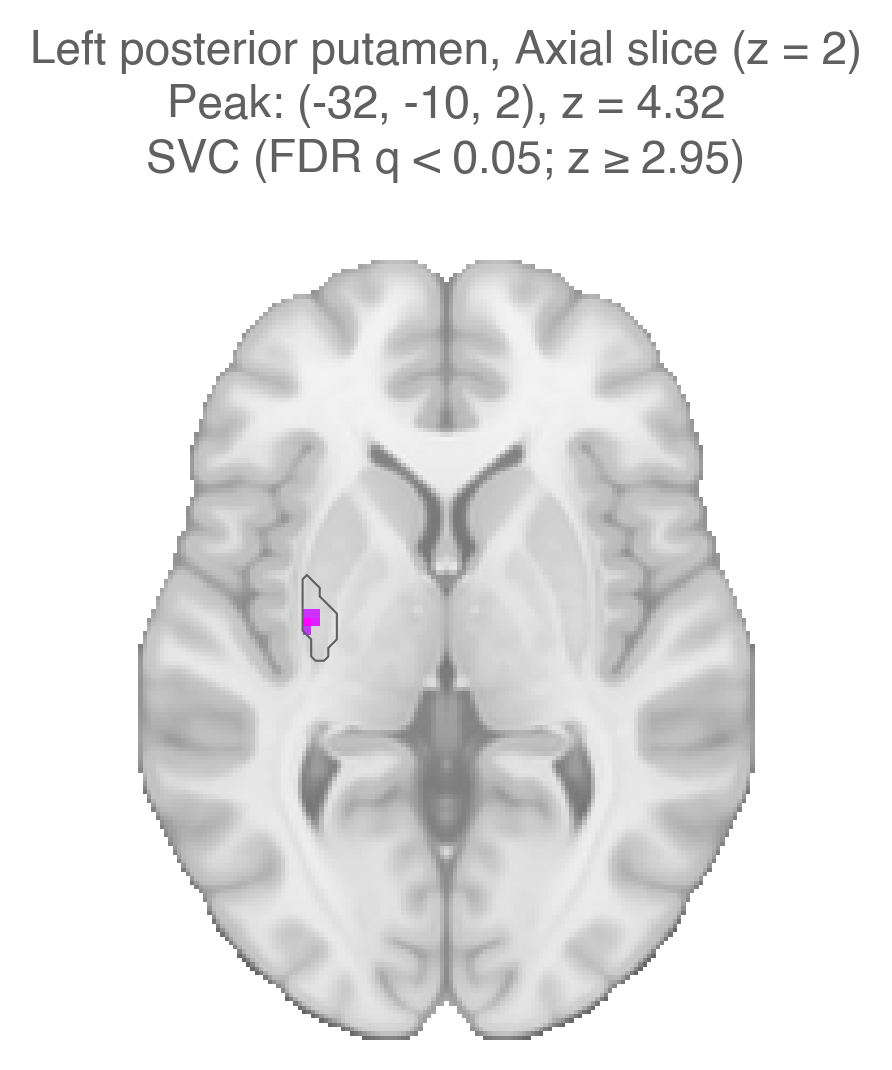

In [6]:
def plot_learning_related_putamen_svc_panel_d(
    *,
    RESULTS_DIRECTORY: str,
    FIGURES_DIRECTORY: str,
    zmap_relpath: str = os.path.join("activation_analysis", "z_score.nii"),
    roi_relpath: str = os.path.join("rois", "left_posterior_putamen.nii"),
    outname: str = "figure-2_panel-D.png",
) -> tuple[plt.Figure, dict]:
    z_score = load_img(os.path.join(RESULTS_DIRECTORY, zmap_relpath))
    roi = load_img(os.path.join(RESULTS_DIRECTORY, roi_relpath))

    roi_rs = resample_to_img(roi, z_score, interpolation="nearest")

    z_thr_img, threshold = threshold_stats_img(
        z_score,
        alpha=0.05,
        height_control="fdr",
        cluster_threshold=0,
        mask_img=roi_rs,
        two_sided=True,
    )

    thr_data = np.asarray(z_thr_img.get_fdata())

    if np.any(thr_data != 0):
        peak_ijk = np.unravel_index(np.nanargmax(np.abs(thr_data)), thr_data.shape)
        peak_xyz = coord_transform(*peak_ijk, z_thr_img.affine)
        peak_z = float(thr_data[peak_ijk])
        best_z = float(peak_xyz[2])
    else:
        roi_data = np.asarray(roi_rs.get_fdata()) > 0
        ijk = np.array(np.where(roi_data)).mean(axis=1)
        peak_xyz = coord_transform(*ijk, roi_rs.affine)
        peak_z = np.nan
        best_z = float(peak_xyz[2])

    p_thresh_two_sided = 2.0 * (1.0 - norm.cdf(abs(threshold)))

    fig = plt.figure(figsize=(2.2, 2.6))
    display = plotting.plot_stat_map(
        z_thr_img,
        figure=fig,
        bg_img=datasets.load_mni152_template(),
        display_mode="z",
        cut_coords=[2],
        threshold=threshold,
        cmap="cool",
        colorbar=False,
        black_bg=False,
        annotate=False,
        draw_cross=False,
        title="",
    )

    display.add_contours(
        roi_rs,
        levels=[0.5],
        linewidths=0.5,
        colors="#606060",
    )

    meta = (
        f"Left posterior putamen, Axial slice (z = {peak_xyz[2]:.0f})"
        f"\nPeak: ({peak_xyz[0]:.0f}, {peak_xyz[1]:.0f}, {peak_xyz[2]:.0f})"
        + (f", z = {peak_z:.2f}" if np.isfinite(peak_z) else "")
        + f"\nSVC (FDR q < 0.05; z ≥ {threshold:.2f})"
    )

    fig.subplots_adjust(bottom=0.16)
    fig.text(
        0.5, 1.1, meta,
        fontsize=11,
        color="#606060",
        ha="center",
        va="bottom",
        linespacing=1.3,
    )

    outpath = os.path.join(FIGURES_DIRECTORY, outname)
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    fig.savefig(outpath, dpi=300, bbox_inches="tight")

    info = {
        "threshold_z": float(threshold),
        "p_thresh_two_sided": float(p_thresh_two_sided),
        "peak_xyz": tuple(float(v) for v in peak_xyz),
        "peak_z": float(peak_z) if np.isfinite(peak_z) else np.nan,
        "best_z": float(best_z),
        "outpath": outpath,
    }
    return fig, info


# Example usage:
fig, info = plot_learning_related_putamen_svc_panel_d(
    RESULTS_DIRECTORY=RESULTS_DIRECTORY,
    FIGURES_DIRECTORY=FIGURES_DIRECTORY,
    outname="figure-2_panel-D.png",
)
print(f"SVC FDR z-threshold: {info['threshold_z']:.3f}")
